In [1]:
import os
import sys
import json
import matplotlib

import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import seaborn as sns
import sklearn.metrics
import tacco as tc
import time 
import tracemalloc 



In [ ]:
import os
import scanpy as sc
import anndata as ad


# -------------------------------------------------------------------
# Set this to the directory containing your input .h5ad files.
# -------------------------------------------------------------------

DATA_DIR = os.environ.get("XENIUM_DATA_DIR", "path/to/data")


# -------------------------------------------------------------------
# Load samples
# -------------------------------------------------------------------

sample_files = {
    "NC1": "sample_NC1.h5ad",
    "C2": "sample_C2.h5ad",
    "C4": "sample_C4.h5ad",
    "C3": "sample_C3.h5ad",
    "NC2": "sample_NC2.h5ad",
    "NC3": "sample_NC3.h5ad",
    "C1": "sample_C1.h5ad",
    "NC4": "sample_NC4.h5ad",
    "S_C5": "sample_S_C5.h5ad",
    "S_NC13": "sample_S_NC13.h5ad",
    "S_C6": "sample_S_C6.h5ad",
    "S_C7": "sample_S_C7.h5ad",
    "NC8": "sample_NC8.h5ad",
    "NC5": "sample_NC5.h5ad",
    "S_C10": "sample_S_C10.h5ad",
    "S_C9": "sample_S_C9.h5ad",
    "S_C8": "sample_S_C8.h5ad",
}


# Load all AnnData objects
adatas = {
    sample: sc.read(os.path.join(DATA_DIR, filename))
    for sample, filename in sample_files.items()
}


# -------------------------------------------------------------------
# Concatenate samples
# -------------------------------------------------------------------

adata_combined = ad.concat(
    list(adatas.values()),
    axis=0,
    join="outer",
    label="sample",
    keys=list(adatas.keys()),
)


# -------------------------------------------------------------------
# Assign experimental conditions
# -------------------------------------------------------------------

condition_map = {
    "NC1": "Non-Cytopenic",
    "NC2": "Non-Cytopenic",
    "NC3": "Non-Cytopenic",
    "NC4": "Non-Cytopenic",
    "S_NC13": "Non-Cytopenic",

    "C1": "Cytopenic",
    "C2": "Cytopenic",
    "C3": "Cytopenic",
    "C4": "Cytopenic",
    "S_C5": "Cytopenic",
    "S_C6": "Cytopenic",
    "S_C7": "Cytopenic",
    "S_C8": "Cytopenic",
    "S_C9": "Cytopenic",
    "S_C10": "Cytopenic",
}


adata_combined.obs["condition"] = adata_combined.obs["sample"].map(condition_map)



In [26]:

# Convert index to string type before making names unique
adata_combined.obs.index = adata_combined.obs.index.astype(str)

# Now make observation names unique
adata_combined.obs_names_make_unique()


duplicates = adata_combined.obs_names[adata_combined.obs_names.duplicated()]
print(f"Number of duplicated cell names after making unique: {len(duplicates)}")

Number of duplicated cell names after making unique: 0


In [27]:
cyt = adata_combined[adata_combined.obs['condition']=='Cytopenic']
noncyt = adata_combined[adata_combined.obs['condition']=='Non-Cytopenic']


In [ ]:
mes_infl = [ "IL6", "CCL26", "CCL2" , "CXCL8", "CXCL2", "CXCL5", "CXCL3","PTGS2"]
overlap_mes_infl = list(set(mes_infl) & set(noncyt.var_names))
sc.tl.score_genes(noncyt, overlap_mes_infl, score_name='mes_infl score')
sc.tl.score_genes(cyt, overlap_mes_infl, score_name='mes_infl score')


/usr/local/Caskroom/mambaforge/base/envs/TACCO_env/lib/python3.12/site-packages/scanpy/tools/_score_genes.py:178: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
/usr/local/Caskroom/mambaforge/base/envs/TACCO_env/lib/python3.12/site-packages/scanpy/tools/_score_genes.py:178: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


In [29]:
import matplotlib.cm as cm


In [39]:
# Plot inflammatory mesenchymal score by individual sample
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract mesenchymal cells from both conditions
cyt_mes = cyt[cyt.obs['Tacco_pred_cell_type'].isin(['Infl.mesenchymal','Mesenchymal','Myeloma.mesenchymal'])]
noncyt_mes = noncyt[noncyt.obs['Tacco_pred_cell_type'].isin(['Infl.mesenchymal','Mesenchymal','Myeloma.mesenchymal'])]

# Create combined dataframe
combined_df = pd.concat([
    cyt_mes.obs[['mes_infl score', 'sample', 'condition', 'Tacco_pred_cell_type']],
    noncyt_mes.obs[['mes_infl score', 'sample', 'condition', 'Tacco_pred_cell_type']]
])

# Count samples per condition
sample_counts = combined_df.groupby(['condition', 'sample']).size().reset_index(name='cell_count')
print("Sample cell counts:")
print(sample_counts)



Sample cell counts:
        condition  sample  cell_count
0       Cytopenic      C1        2544
1       Cytopenic      C2        3229
2       Cytopenic      C3        2515
3       Cytopenic      C4        8796
4       Cytopenic   S_C10        3582
5       Cytopenic    S_C5        6203
6       Cytopenic    S_C6        2789
7       Cytopenic    S_C7        2584
8       Cytopenic    S_C8        2179
9       Cytopenic    S_C9        5180
10  Non-Cytopenic     NC1        3458
11  Non-Cytopenic     NC2        2748
12  Non-Cytopenic     NC3        3693
13  Non-Cytopenic     NC4        2804
14  Non-Cytopenic  S_NC13        5509


Mean inflammatory mesenchymal scores by sample:
    sample      condition  mes_infl score
0       C1      Cytopenic       -0.056263
1       C2      Cytopenic       -0.032565
2       C3      Cytopenic        0.013822
3       C4      Cytopenic       -0.040993
4      NC1  Non-Cytopenic       -0.105670
5      NC2  Non-Cytopenic       -0.165802
6      NC3  Non-Cytopenic       -0.196971
7      NC4  Non-Cytopenic       -0.182912
8    S_C10      Cytopenic        0.035321
9     S_C5      Cytopenic       -0.052613
10    S_C6      Cytopenic       -0.040200
11    S_C7      Cytopenic       -0.023270
12    S_C8      Cytopenic       -0.026695
13    S_C9      Cytopenic       -0.032034
14  S_NC13  Non-Cytopenic       -0.153662
T-test p-value: 1.6029e-04
Mann-Whitney U test p-value: 6.6600e-04

Group statistics (sample means):
       condition      mean    median       std  count
0      Cytopenic -0.025549 -0.032300  0.028833     10
1  Non-Cytopenic -0.161003 -0.165802  0.035044      5


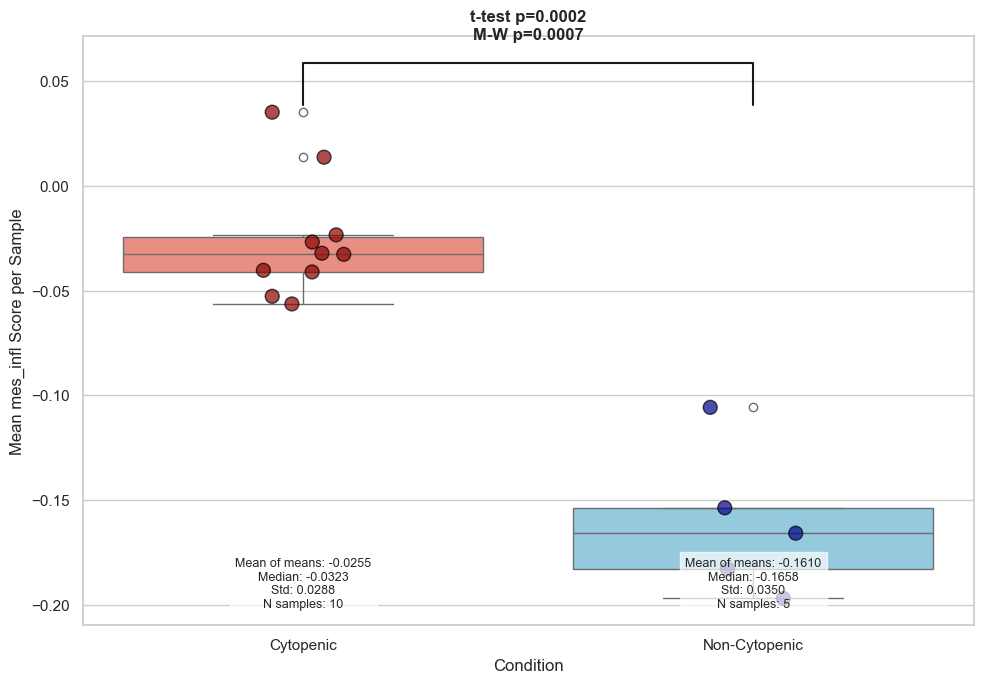

In [ ]:
# Create boxplot comparing the mean inflammatory mesenchymal score per sample between conditions
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats
import numpy as np

# Calculate mean score per sample
sample_means = combined_df.groupby(['sample', 'condition'])['mes_infl score'].mean().reset_index()
print("Mean inflammatory mesenchymal scores by sample:")
print(sample_means)

# Create figure for the boxplot
plt.figure(figsize=(10, 7))
sns.set(style="whitegrid")

# Create boxplot of sample means grouped by condition
ax = sns.boxplot(x='condition', y='mes_infl score', data=sample_means, 
                 palette={'Cytopenic': 'salmon', 'Non-Cytopenic': 'skyblue'})

# Add individual sample points with larger size and slight jitter for better visibility
# Use a consistent random seed to ensure reproducible jitter
np.random.seed(42)
scatter = sns.stripplot(x='condition', y='mes_infl score', data=sample_means, 
              size=10, jitter=True, edgecolor='black', linewidth=1, alpha=0.7,
              palette={'Cytopenic': 'darkred', 'Non-Cytopenic': 'darkblue'})

# Perform statistical tests to compare means between conditions
cytopenic_means = sample_means[sample_means['condition'] == 'Cytopenic']['mes_infl score']
noncytopenic_means = sample_means[sample_means['condition'] == 'Non-Cytopenic']['mes_infl score']

# Try to perform statistical tests if there's enough data
if len(cytopenic_means) > 1 and len(noncytopenic_means) > 1:
    # T-test (if sample sizes are sufficient)
    t_stat, t_pval = scipy.stats.ttest_ind(cytopenic_means, noncytopenic_means, equal_var=False)
    print(f"T-test p-value: {t_pval:.4e}")
    
    # Mann-Whitney U test (non-parametric, better for small samples)
    try:
        u_stat, u_pval = scipy.stats.mannwhitneyu(cytopenic_means, noncytopenic_means, alternative='two-sided')
        print(f"Mann-Whitney U test p-value: {u_pval:.4e}")
        
        # Add p-value annotation
        y_pos = max(sample_means['mes_infl score']) * 1.1
        plt.plot([0, 0, 1, 1], [y_pos, y_pos + 0.02, y_pos + 0.02, y_pos], color='k', lw=1.5)
        plt.text(0.5, y_pos + 0.03, f"t-test p={t_pval:.4f}\nM-W p={u_pval:.4f}", 
                ha='center', va='bottom', fontweight='bold')
    except:
        # If Mann-Whitney fails (e.g., too few samples), just show t-test
        y_pos = max(sample_means['mes_infl score']) * 1.1
        plt.plot([0, 0, 1, 1], [y_pos, y_pos + 0.02, y_pos + 0.02, y_pos], color='k', lw=1.5)
        plt.text(0.5, y_pos + 0.03, f"t-test p={t_pval:.4f}", 
                ha='center', va='bottom', fontweight='bold')

# Calculate and display group statistics
group_stats = sample_means.groupby('condition')['mes_infl score'].agg(['mean', 'median', 'std', 'count']).reset_index()
print("\nGroup statistics (sample means):")
print(group_stats)

# Get unique conditions from the data
condition_labels = sample_means['condition'].unique()

# Add statistics as text on the plot
for i, condition in enumerate(condition_labels):
    stats = group_stats[group_stats['condition'] == condition]
    plt.text(i, sample_means['mes_infl score'].min() * 0.9,
             f"Mean of means: {stats['mean'].values[0]:.4f}\nMedian: {stats['median'].values[0]:.4f}\nStd: {stats['std'].values[0]:.4f}\nN samples: {stats['count'].values[0]}", 
             ha='center', va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

plt.ylabel("Mean mes_infl Score per Sample", fontsize=12)
plt.xlabel("Condition", fontsize=12)
plt.tight_layout()

plt.show()

In [ ]:
HSC_sen = ["AREG", "JUNB",'CXCL8','CXCL3'
              "CDKN1A", "CDKN2A", "GLB1", "EREG","PLAUR",  "NFKB1","CEBPB"]
overlap_HSC_sen = list(set(HSC_sen) & set(noncyt.var_names))
sc.tl.score_genes(noncyt, overlap_HSC_sen, score_name='HSC_sen score')
sc.tl.score_genes(cyt, overlap_HSC_sen, score_name='HSC_sen score')

In [48]:
# Plot inflammatory mesenchymal score by individual sample
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract mesenchymal cells from both conditions
cyt_mes = cyt[cyt.obs['Tacco_pred_cell_type'].isin(['HSC'])]
noncyt_mes = noncyt[noncyt.obs['Tacco_pred_cell_type'].isin(['HSC'])]


# Create combined dataframe
combined_df = pd.concat([
    cyt_mes.obs[['HSC_sen score', 'sample', 'condition', 'Tacco_pred_cell_type']],
    noncyt_mes.obs[['HSC_sen score', 'sample', 'condition', 'Tacco_pred_cell_type']]
])

# Count samples per condition
sample_counts = combined_df.groupby(['condition', 'sample']).size().reset_index(name='cell_count')


    sample      condition  HSC_sen score
0       C1      Cytopenic       0.061376
1       C2      Cytopenic       0.097563
2       C3      Cytopenic       0.206309
3       C4      Cytopenic       0.179628
4      NC1  Non-Cytopenic       0.004666
5      NC2  Non-Cytopenic      -0.174164
6      NC3  Non-Cytopenic      -0.087124
7      NC4  Non-Cytopenic      -0.029667
8    S_C10      Cytopenic       0.366892
9     S_C5      Cytopenic       0.157704
10    S_C6      Cytopenic       0.366414
11    S_C7      Cytopenic       0.003463
12    S_C8      Cytopenic       0.352317
13    S_C9      Cytopenic       0.180446
14  S_NC13  Non-Cytopenic       0.060493
T-test p-value: 1.3484e-03
Mann-Whitney U test p-value: 2.6640e-03

Group statistics (sample means):
       condition      mean    median       std  count
0      Cytopenic  0.197211  0.180037  0.128941     10
1  Non-Cytopenic -0.045159 -0.029667  0.089845      5


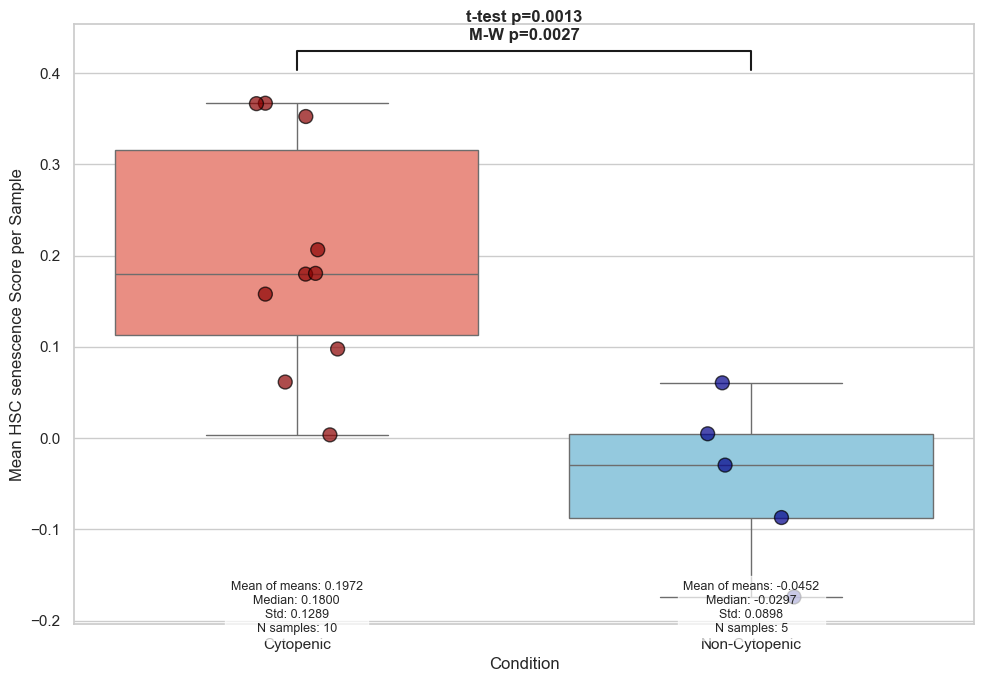

In [ ]:
# Create boxplot comparing the mean inflammatory mesenchymal score per sample between conditions
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats
import numpy as np

# Calculate mean score per sample
sample_means = combined_df.groupby(['sample', 'condition'])['HSC_sen score'].mean().reset_index()
print(sample_means)

# Create figure for the boxplot
plt.figure(figsize=(10, 7))
sns.set(style="whitegrid")

# Create boxplot of sample means grouped by condition
ax = sns.boxplot(x='condition', y='HSC_sen score', data=sample_means, 
                 palette={'Cytopenic': 'salmon', 'Non-Cytopenic': 'skyblue'})

# Add individual sample points with larger size and slight jitter for better visibility
# Use a consistent random seed to ensure reproducible jitter
np.random.seed(42)
scatter = sns.stripplot(x='condition', y='HSC_sen score', data=sample_means, 
              size=10, jitter=True, edgecolor='black', linewidth=1, alpha=0.7,
              palette={'Cytopenic': 'darkred', 'Non-Cytopenic': 'darkblue'})

# Perform statistical tests to compare means between conditions
cytopenic_means = sample_means[sample_means['condition'] == 'Cytopenic']['HSC_sen score']
noncytopenic_means = sample_means[sample_means['condition'] == 'Non-Cytopenic']['HSC_sen score']

# Try to perform statistical tests if there's enough data
if len(cytopenic_means) > 1 and len(noncytopenic_means) > 1:
    # T-test (if sample sizes are sufficient)
    t_stat, t_pval = scipy.stats.ttest_ind(cytopenic_means, noncytopenic_means, equal_var=False)
    print(f"T-test p-value: {t_pval:.4e}")
    
    # Mann-Whitney U test (non-parametric, better for small samples)
    try:
        u_stat, u_pval = scipy.stats.mannwhitneyu(cytopenic_means, noncytopenic_means, alternative='two-sided')
        print(f"Mann-Whitney U test p-value: {u_pval:.4e}")
        
        # Add p-value annotation
        y_pos = max(sample_means['HSC_sen score']) * 1.1
        plt.plot([0, 0, 1, 1], [y_pos, y_pos + 0.02, y_pos + 0.02, y_pos], color='k', lw=1.5)
        plt.text(0.5, y_pos + 0.03, f"t-test p={t_pval:.4f}\nM-W p={u_pval:.4f}", 
                ha='center', va='bottom', fontweight='bold')
    except:
        # If Mann-Whitney fails (e.g., too few samples), just show t-test
        y_pos = max(sample_means['HSC_sen score']) * 1.1
        plt.plot([0, 0, 1, 1], [y_pos, y_pos + 0.02, y_pos + 0.02, y_pos], color='k', lw=1.5)
        plt.text(0.5, y_pos + 0.03, f"t-test p={t_pval:.4f}", 
                ha='center', va='bottom', fontweight='bold')

# Calculate and display group statistics
group_stats = sample_means.groupby('condition')['HSC_sen score'].agg(['mean', 'median', 'std', 'count']).reset_index()
print("\nGroup statistics (sample means):")
print(group_stats)

# Get unique conditions from the data
condition_labels = sample_means['condition'].unique()

# Add statistics as text on the plot
for i, condition in enumerate(condition_labels):
    stats = group_stats[group_stats['condition'] == condition]
    plt.text(i, sample_means['HSC_sen score'].min() * 0.9,
             f"Mean of means: {stats['mean'].values[0]:.4f}\nMedian: {stats['median'].values[0]:.4f}\nStd: {stats['std'].values[0]:.4f}\nN samples: {stats['count'].values[0]}", 
             ha='center', va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

plt.ylabel("Mean HSC senescence Score per Sample", fontsize=12)
plt.xlabel("Condition", fontsize=12)
plt.tight_layout()

plt.show()